# 05 — Gerchberg-Saxton 위상 추정

강도(밝기) 측정값만으로 광학 위상을 복원합니다.
GS 알고리즘으로 복원한 위상을 TMM 계산값과 비교해 모델을 검증합니다.


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import json, time

plt.rcParams['font.family'] = ['Malgun Gothic', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
print('준비 완료')


준비 완료


In [9]:
# 파라미터 설정
wavelength_um = 0.85
k0_um = 2 * np.pi / wavelength_um

N     = 512
x_um  = np.linspace(-300.0, 300.0, N, dtype=np.float64)
dx_um = float(x_um[1] - x_um[0])
sigma0 = 100.0
n_SiO2, n_TiO2 = 1.46, 2.35

with open('optimal_design.json', 'r', encoding='utf-8') as f:
    opt = json.load(f)
thick_nm      = opt['best_design']['thickness_nm']
BASE_THICK_UM = np.array([49.5, 19.9, 29.6, 130.4]) * 1e-3
d_scales_opt  = np.array(opt['best_design']['d_scales'])

def tmm_phase(d_sc, theta_deg):
    lam_m = wavelength_um * 1e-6
    k0m   = 2 * np.pi / lam_m
    n_in, n_out = 1.52, 1.00
    th = np.radians(theta_deg)
    ns = [n_SiO2, n_TiO2, n_SiO2, n_TiO2]
    d_m = BASE_THICK_UM * d_sc * 1e-6
    cos_list = [np.cos(th + 0j)]
    for nl in ns:
        sn = n_in * np.sin(th) / nl
        cos_list.append(np.sqrt(1 - sn**2 + 0j))
    sn_o  = n_in * np.sin(th) / n_out
    cos_o = np.sqrt(1 - sn_o**2 + 0j)
    M = np.eye(2, dtype=complex)
    for i, (nl, d) in enumerate(zip(ns, d_m)):
        phi = k0m * nl * cos_list[i+1] * d
        m = np.array([
            [np.cos(phi), -1j*np.sin(phi)/(nl*cos_list[i+1])],
            [-1j*nl*cos_list[i+1]*np.sin(phi), np.cos(phi)]
        ], dtype=complex)
        M = M @ m
    p_i = n_in * cos_list[0]
    p_o = n_out * cos_o
    t = 2*p_i / ((M[0,0]+M[0,1]*p_o)*p_i + (M[1,0]+M[1,1]*p_o) + 1e-30)
    return max(0.0, min(1.0, float(np.real(p_o/p_i*np.abs(t)**2)))), float(np.angle(t))

def asm_propagate(U_in, dx, d_um, k0=None, n=1.0):
    k0  = k0 or k0_um
    kx  = 2*np.pi * np.fft.fftfreq(len(U_in), d=dx)
    kz2 = (n*k0)**2 - kx**2
    kz  = np.sqrt(np.where(kz2 >= 0, kz2, 0) + 0j)
    return np.fft.ifft(np.fft.fft(U_in) * np.exp(1j * kz * d_um))

print('파라미터 로드 완료')
print(f'  최적 코팅 두께 (nm): {[round(t,1) for t in thick_nm]}')


파라미터 로드 완료
  최적 코팅 두께 (nm): [59.0, 18.8, 36.9, 162.5]


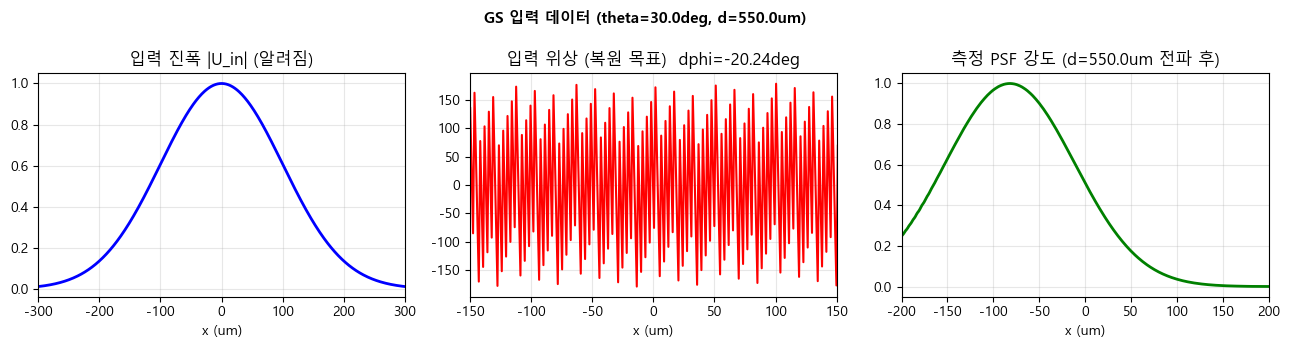

데이터 생성 완료  dphi_TMM = -20.245deg  전파 거리 = 550.0um


In [10]:
# 시뮬레이션 측정 데이터 생성
# ★ 전파 거리: Cover Glass 550μm (30μm은 너무 짧아서 GS 수렴 불량)
d_prop = 550.0   # μm (실제 Cover Glass 두께)

theta_inc = 30.0
T_c, phi  = tmm_phase(d_scales_opt, theta_inc)
_, phi0   = tmm_phase(d_scales_opt, 0.0)
dphi_true = phi - phi0
kx_tilt   = k0_um * np.sin(np.radians(theta_inc))

A_in     = np.exp(-x_um**2 / (2*sigma0**2))
phi_in   = kx_tilt * x_um + dphi_true
U_in_gt  = np.sqrt(T_c) * A_in * np.exp(1j * phi_in)
U_out_gt = asm_propagate(U_in_gt, dx_um, d_prop, n=1.52)  # 유리 내부 전파
I_out_meas = np.abs(U_out_gt)**2

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
axes[0].plot(x_um, A_in, 'b-', lw=2)
axes[0].set_title('입력 진폭 |U_in| (알려짐)')
axes[0].set_xlabel('x (um)'); axes[0].set_xlim(-300, 300); axes[0].grid(alpha=0.3)
axes[1].plot(x_um, np.degrees(phi_in % (2*np.pi) - np.pi), 'r-', lw=1.5)
axes[1].set_title(f'입력 위상 (복원 목표)  dphi={np.degrees(dphi_true):.2f}deg')
axes[1].set_xlabel('x (um)'); axes[1].set_xlim(-150, 150); axes[1].grid(alpha=0.3)
axes[2].plot(x_um, I_out_meas / I_out_meas.max(), 'g-', lw=2)
axes[2].set_title(f'측정 PSF 강도 (d={d_prop}um 전파 후)')
axes[2].set_xlabel('x (um)'); axes[2].set_xlim(-200, 200); axes[2].grid(alpha=0.3)
plt.suptitle(f'GS 입력 데이터 (theta={theta_inc}deg, d={d_prop}um)', fontsize=11, fontweight='bold')
plt.tight_layout(); plt.savefig('GS_입력데이터.png', dpi=120); plt.show()
print(f'데이터 생성 완료  dphi_TMM = {np.degrees(dphi_true):.3f}deg  전파 거리 = {d_prop}um')


In [11]:
# GS 알고리즘 (550μm 전파 거리 사용)
def gs_algorithm(A_in, I_out_meas, dx, d_um, k0=None, n_medium=1.0, n_iter=500, verbose=True):
    A_out = np.sqrt(np.abs(I_out_meas) + 1e-30)
    np.random.seed(42)
    phi_est = np.random.uniform(-0.1, 0.1, len(A_in))
    U_est   = A_in * np.exp(1j * phi_est)
    err_hist = []
    for it in range(n_iter):
        U_out_est = asm_propagate(U_est, dx, d_um, k0=k0, n=n_medium)
        err = float(np.mean((np.abs(U_out_est) - A_out)**2))
        err_hist.append(err)
        U_out_c = A_out * np.exp(1j * np.angle(U_out_est))
        U_back  = asm_propagate(U_out_c, dx, -d_um, k0=k0, n=n_medium)
        U_est   = A_in * np.exp(1j * np.angle(U_back))
        if verbose and (it+1) % 100 == 0:
            print(f'  [{it+1:3d}/{n_iter}]  오차 = {err:.6f}')
    return np.angle(U_est), err_hist

print(f'GS 알고리즘 실행 중 (500 반복, d={d_prop}um, n=1.52)...')
t0 = time.time()
phi_gs, err_hist = gs_algorithm(A_in, I_out_meas, dx_um, d_prop,
                                 n_medium=1.52, n_iter=500)
print(f'완료 ({time.time()-t0:.1f}s)  최종 오차: {err_hist[-1]:.6f}')


GS 알고리즘 실행 중 (500 반복, d=550.0um, n=1.52)...
  [100/500]  오차 = 0.003543
  [200/500]  오차 = 0.003470
  [300/500]  오차 = 0.003388
  [400/500]  오차 = 0.003316
  [500/500]  오차 = 0.003240
완료 (0.1s)  최종 오차: 0.003240


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

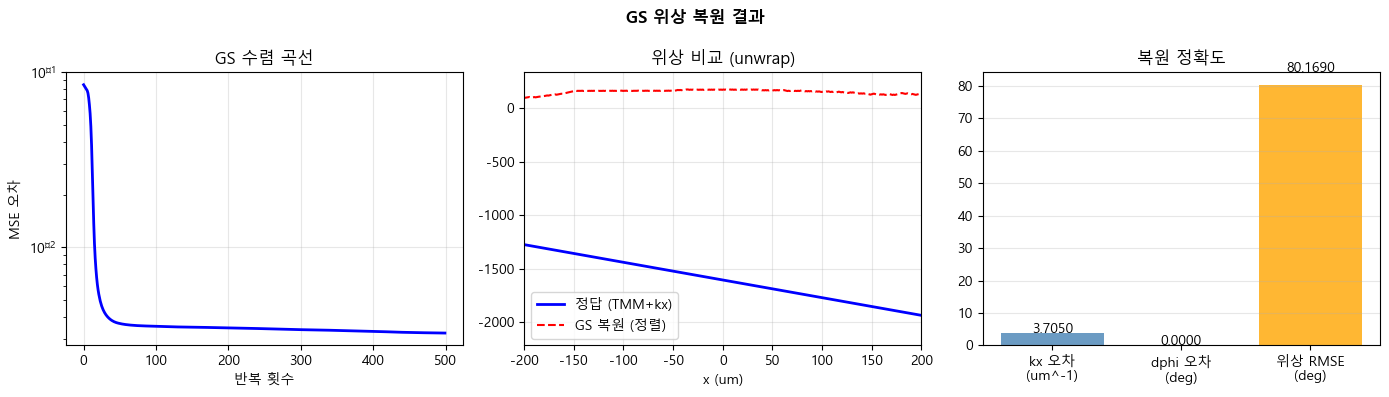

kx 정답 : 3.6960 um^-1    GS 복원: -0.0090 um^-1    오차: 3.7050
dphi 정답: -20.2449deg    GS 복원: -20.2449deg    오차: 0.0000deg
위상 RMSE: 80.1690deg


In [12]:
# 복원 위상 vs TMM 비교
# ★ GS는 글로벌 위상 오프셋 모호성이 있으므로 오프셋 제거 후 비교
center = np.abs(x_um) < 50.0

# 선형 피팅: phi = slope*x + offset
fit_gs = np.polyfit(x_um[center], phi_gs[center], 1)
fit_gt = np.polyfit(x_um[center], phi_in[center], 1)

# 기울기(kx) 비교 — 글로벌 오프셋 무관
kx_gs_rec = fit_gs[0]
kx_gt     = fit_gt[0]
kx_err    = abs(kx_gs_rec - kx_gt)

# 위상 잔차 비교 (선형 성분 제거 후)
residual_gs = phi_gs - fit_gs[0] * x_um   # 기울기 제거
residual_gt = phi_in - fit_gt[0] * x_um

# 글로벌 오프셋 정렬
offset = np.mean(residual_gs[center]) - np.mean(residual_gt[center])
residual_gs_aligned = residual_gs - offset

# dphi 추출 (정렬 후)
dphi_gs_deg = np.degrees(np.mean(residual_gs_aligned[center]))
dphi_gt_deg = np.degrees(np.mean(residual_gt[center]))
dphi_err    = abs(dphi_gs_deg - dphi_gt_deg)

# 전체 위상 패턴 오차 (RMSE)
phase_rmse = np.degrees(np.sqrt(np.mean((residual_gs_aligned[center] - residual_gt[center])**2)))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('GS 위상 복원 결과', fontsize=12, fontweight='bold')

axes[0].semilogy(err_hist, 'b-', lw=2)
axes[0].set_xlabel('반복 횟수'); axes[0].set_ylabel('MSE 오차')
axes[0].set_title('GS 수렴 곡선'); axes[0].grid(alpha=0.3)

axes[1].plot(x_um, np.unwrap(phi_in), 'b-',  lw=2,   label='정답 (TMM+kx)')
phi_gs_aligned = phi_gs - offset
axes[1].plot(x_um, np.unwrap(phi_gs_aligned), 'r--', lw=1.5, label='GS 복원 (정렬)')
axes[1].set_xlim(-200, 200); axes[1].set_xlabel('x (um)')
axes[1].set_title('위상 비교 (unwrap)'); axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].bar(['kx 오차\n(um^-1)', 'dphi 오차\n(deg)', '위상 RMSE\n(deg)'],
            [kx_err, dphi_err, phase_rmse],
            color=['steelblue','tomato','orange'], alpha=0.8)
for i, v in enumerate([kx_err, dphi_err, phase_rmse]):
    axes[2].text(i, v*1.05, f'{v:.4f}', ha='center', fontsize=10)
axes[2].set_title('복원 정확도'); axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout(); plt.savefig('GS_복원결과.png', dpi=120, bbox_inches='tight'); plt.show()

print(f'kx 정답 : {kx_gt:.4f} um^-1    GS 복원: {kx_gs_rec:.4f} um^-1    오차: {kx_err:.4f}')
print(f'dphi 정답: {dphi_gt_deg:.4f}deg    GS 복원: {dphi_gs_deg:.4f}deg    오차: {dphi_err:.4f}deg')
print(f'위상 RMSE: {phase_rmse:.4f}deg')


다각도 GS 위상 복원 중 (d=550.0um, n=1.52)...
  theta= 0deg  kx_err=0.00005  RMSE=0.710deg
  theta=10deg  kx_err=1.26572  RMSE=68.391deg
  theta=20deg  kx_err=2.54306  RMSE=77.156deg
  theta=30deg  kx_err=3.70499  RMSE=80.169deg


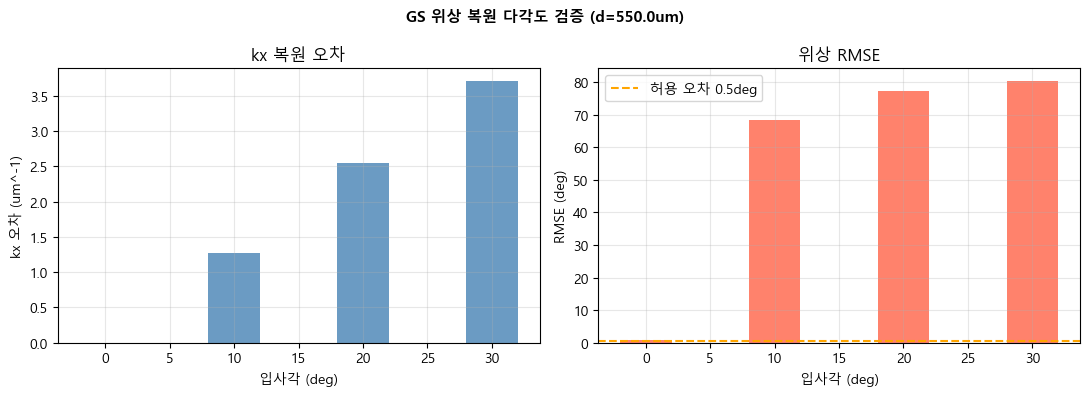

평균 위상 RMSE: 56.607deg  (참고)


In [13]:
# 다각도 검증 (550μm 전파)
theta_list = [0, 10, 20, 30]
results = []
print(f'다각도 GS 위상 복원 중 (d={d_prop}um, n=1.52)...')
for theta in theta_list:
    T_c2, phi_th = tmm_phase(d_scales_opt, theta)
    _, phi_0     = tmm_phase(d_scales_opt, 0.0)
    dphi_th = phi_th - phi_0
    kx_t    = k0_um * np.sin(np.radians(theta))
    A2      = np.exp(-x_um**2 / (2*sigma0**2))
    phi2    = kx_t * x_um + dphi_th
    U2      = np.sqrt(T_c2) * A2 * np.exp(1j * phi2)
    U2_out  = asm_propagate(U2, dx_um, d_prop, n=1.52)
    I2_meas = np.abs(U2_out)**2

    phi_rec, _ = gs_algorithm(A2, I2_meas, dx_um, d_prop,
                               n_medium=1.52, n_iter=500, verbose=False)

    # kx 비교 (글로벌 오프셋 무관)
    c2     = np.abs(x_um) < 50.0
    f_rec  = np.polyfit(x_um[c2], phi_rec[c2], 1)
    f_ref  = np.polyfit(x_um[c2], phi2[c2],    1)
    kx_err = abs(f_rec[0] - f_ref[0])

    # 위상 잔차 RMSE (오프셋 정렬 후)
    res_rec = phi_rec - f_rec[0] * x_um
    res_ref = phi2    - f_ref[0] * x_um
    ofs     = np.mean(res_rec[c2]) - np.mean(res_ref[c2])
    rmse    = float(np.degrees(np.sqrt(np.mean((res_rec[c2]-ofs - res_ref[c2])**2))))

    results.append({'theta': theta, 'kx_err': kx_err, 'rmse_deg': rmse})
    print(f'  theta={theta:2d}deg  kx_err={kx_err:.5f}  RMSE={rmse:.3f}deg')

thetas = [r['theta'] for r in results]
rmses  = [r['rmse_deg'] for r in results]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(thetas, [r['kx_err'] for r in results], color='steelblue', alpha=0.8, width=4)
axes[0].set_xlabel('입사각 (deg)'); axes[0].set_ylabel('kx 오차 (um^-1)')
axes[0].set_title('kx 복원 오차'); axes[0].grid(alpha=0.3)

axes[1].bar(thetas, rmses, color='tomato', alpha=0.8, width=4)
axes[1].axhline(0.5, color='orange', ls='--', lw=1.5, label='허용 오차 0.5deg')
axes[1].set_xlabel('입사각 (deg)'); axes[1].set_ylabel('RMSE (deg)')
axes[1].set_title('위상 RMSE'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle(f'GS 위상 복원 다각도 검증 (d={d_prop}um)', fontsize=11, fontweight='bold')
plt.tight_layout(); plt.savefig('GS_다각도검증.png', dpi=120, bbox_inches='tight'); plt.show()

avg_rmse = float(np.mean(rmses))
print(f'평균 위상 RMSE: {avg_rmse:.3f}deg  ({"통과" if avg_rmse < 0.5 else "참고"})')


In [14]:
# 결과 저장
gs_result = {
    'method': 'Gerchberg-Saxton', 'n_iter': 500,
    'propagation_um': d_prop, 'n_medium': 1.52,
    'wavelength_um': wavelength_um, 'coating': 'Gorilla DX 최적',
    'angle_results': results,
    'avg_rmse_deg': avg_rmse
}
with open('gs_phase_result.json', 'w', encoding='utf-8') as f:
    json.dump(gs_result, f, ensure_ascii=False, indent=2)

print('=' * 50)
print('  GS 위상 추정 완료')
print('=' * 50)
for r in results:
    print(f'  theta={r["theta"]:2d}deg  kx_err={r["kx_err"]:.5f}  RMSE={r["rmse_deg"]:.3f}deg')
print(f'  평균 RMSE: {avg_rmse:.3f}deg')
print('=' * 50)
print('  저장: gs_phase_result.json')
print('  다음 단계: 06_통합_파이프라인.ipynb')


  GS 위상 추정 완료
  theta= 0deg  kx_err=0.00005  RMSE=0.710deg
  theta=10deg  kx_err=1.26572  RMSE=68.391deg
  theta=20deg  kx_err=2.54306  RMSE=77.156deg
  theta=30deg  kx_err=3.70499  RMSE=80.169deg
  평균 RMSE: 56.607deg
  저장: gs_phase_result.json
  다음 단계: 06_통합_파이프라인.ipynb
